# Set-up

In [1]:
import os
import sys
import torch
import pyfaidx
import numpy as np
import pandas as pd
import seaborn as sns

import seqpro as sp

from bpnetlite.bpnet import BPNet, CountWrapper
from tangermeme.io import extract_loci
from tangermeme.predict import predict

from matplotlib import pyplot as plt
import seaborn as sns; sns.set_style('white')

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
os.chdir("/cellar/users/aklie/projects/igvf/ChromBetaNet")

In [3]:
path_out = "scratch/2025_07_05/day15_ENP_MPRA_design"

# Load genome

In [4]:
chrom_sizes = "/cellar/users/aklie/data/ref/genomes/hg38/hg38.chrom.sizes"
chrom_sizes = pd.read_csv(chrom_sizes, header=None, sep='\t', names=['chrom', 'size'])
chrom_sizes_dict = chrom_sizes.set_index('chrom')['size'].to_dict()

In [5]:
genome_fasta = "/cellar/users/aklie/data/ref/genomes/hg38/hg38.fa"
genome = pyfaidx.Fasta(genome_fasta)

# Load peaks

In [6]:
path_peaks = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/peaks/D15_merged_ENP_peaks.bed"
peaks = pd.read_csv(path_peaks, header=None, sep='\t', names=["chrom", "start", "end", "name", "score", "strand", "signal_value", "p_value", "q_value", "peak"])
peaks = peaks.sort_values('q_value', ascending=False).drop_duplicates(subset=['chrom', 'start', 'end'])
peaks

,chrom,start,end,name,score,strand,signal_value,p_value,q_value,peak
7,chr1,633840,634204,.,1000,.,40.609467,109236.929688,109228.906250,193
109643,chr17,22521248,22521557,.,1000,.,43.419971,34642.917969,34635.835938,150
6,chr1,629813,630101,.,1000,.,8.402439,10337.239258,10330.491211,142
3021,chr1,16612947,16614053,.,1000,.,25.223841,7114.754395,7108.110352,661
112224,chr17,43251568,43251928,.,1000,.,46.463974,6077.647949,6071.098633,146
...,...,...,...,...,...,...,...,...,...,...
125611,chr18,78739087,78739330,.,13,.,1.479915,2.706340,1.309857,94
108848,chr17,17019608,17019854,.,13,.,1.675393,2.705390,1.308933,129
119139,chr18,7063745,7064068,.,13,.,1.617133,2.703760,1.307358,73
267882,chr8,144538109,144538392,.,13,.,1.732673,2.701570,1.305214,185


# Load model

In [7]:
path_model = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/D15_ENP/fold_0/chrombpnet/0.5/models/chrombpnet_nobias.h5"
model = BPNet.from_chrombpnet(path_model).cuda().eval()
count_wrapper = CountWrapper(model).cuda().eval()

# Load sequences

In [8]:
path_bw = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/D15_ENP/fold_0/chrombpnet/0.5/auxiliary/data_unstranded.bw"

In [9]:
X, signals = extract_loci(
    loci=peaks,
    sequences=genome_fasta,
    signals=[path_bw],
    ignore=list('QWERYUIOPSDFHJKLZXVBNM'),
    verbose=True,
)

Loading Loci: 100%|██████████| 233711/233711 [01:16<00:00, 3067.56it/s]


In [10]:
y_counts = predict(
    model=count_wrapper,
    X=X,
    verbose=True,
)

  0%|          | 0/7304 [00:00<?, ?it/s]

100%|██████████| 7304/7304 [03:53<00:00, 31.29it/s]


In [11]:
y_counts.shape

torch.Size([233711, 1])

In [12]:
# Add the predicted counts to the peaks dataframe
peaks["log_counts"] = torch.log(torch.sum(signals, dim=(1,2))).cpu().numpy()
peaks["log_counts_pred"] = y_counts.squeeze().cpu().numpy()

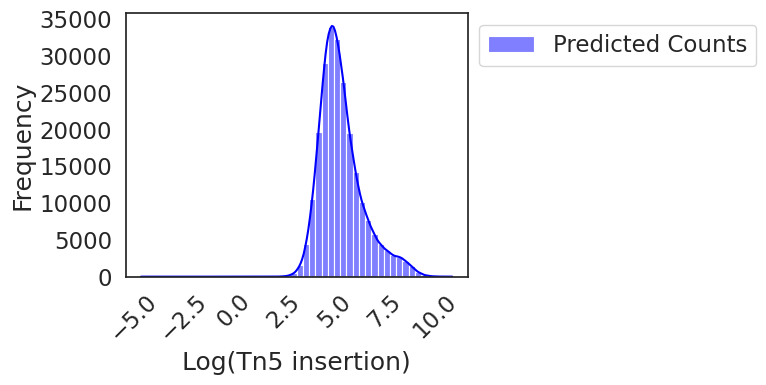

In [13]:
# Plot a beautiful histogram of the predictions 
with sns.plotting_context("notebook", font_scale=1.5):
    fig, ax = plt.subplots(figsize=(8, 4))

    # Plot forward
    sns.histplot(
        peaks["log_counts_pred"],
        bins=50,
        kde=True,
        color='blue',
        label='Predicted Counts',
        ax=ax
    )
    # Move legend outside of the plot
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.xlabel('Log(Tn5 insertion)')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)

    # 
    plt.tight_layout()

In [23]:
# Correlation
corr = peaks["log_counts"].corr(peaks["log_counts_pred"])
corr

0.8247368627872451

Exception ignored in atexit callback: <bound method InteractiveShell.atexit_operations of <ipykernel.zmqshell.ZMQInteractiveShell object at 0x1555512f7650>>
Traceback (most recent call last):
  File "/cellar/users/aklie/opt/miniconda3/envs/eugene_tools/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3952, in atexit_operations
    self._atexit_once()
  File "/cellar/users/aklie/opt/miniconda3/envs/eugene_tools/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3935, in _atexit_once
    self.history_manager.end_session()
  File "/cellar/users/aklie/opt/miniconda3/envs/eugene_tools/lib/python3.11/site-packages/IPython/core/history.py", line 592, in end_session
    self.writeout_cache()
  File "/cellar/users/aklie/opt/miniconda3/envs/eugene_tools/lib/python3.11/site-packages/decorator.py", line 232, in fun
    return caller(func, *(extras + args), **kw)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/cellar/users/aklie/opt/miniconda3/envs/eug

In [19]:
# save dataframe
peaks.to_csv(os.path.join(path_out, "peaks_with_predictions.tsv"), sep="\t", index=False)

# DONE!

---